## Import Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

## Data Collection and Processing

In [2]:
# loading the data from csv file to a pandas dataframe

calories = pd.read_csv('../dataset/calories.csv')

In [3]:
# print the first five rows of the dataframe
calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [4]:
exercise_data = pd.read_csv('../dataset/exercise.csv')

In [5]:
exercise_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


## Combining the two Dataframes

In [6]:
calories_data = pd.concat([exercise_data, calories['Calories']], axis=1)

In [7]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [8]:
# checking the number of rows and columns
calories_data.shape

(15000, 9)

In [9]:
# getting information about the data
calories_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [10]:
# checking for missing values
calories_data.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

## Data Analysis

In [11]:
# getting statistical measures about the data
calories_data.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


## Data Visualization

In [12]:
sns.set()

<Axes: xlabel='count', ylabel='Gender'>

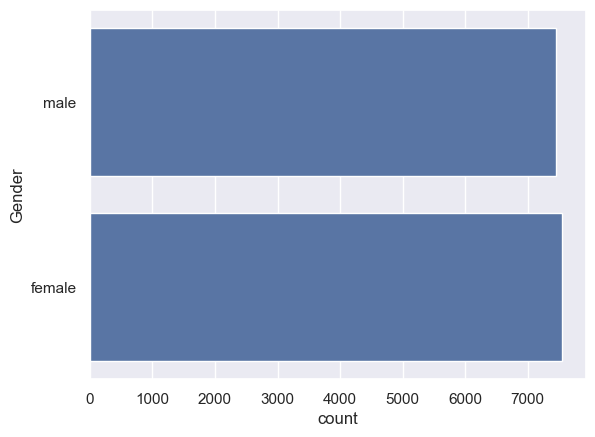

In [13]:
# plotting the gender column in count plot
sns.countplot(calories_data['Gender'])

<Axes: xlabel='Age', ylabel='Count'>

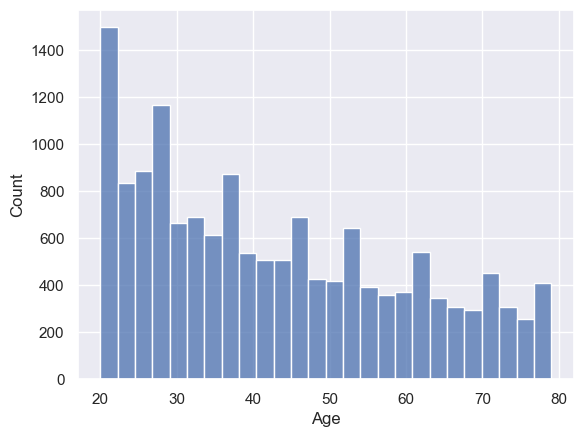

In [14]:
# finding the distribution of 'Age' column
sns.histplot(calories_data['Age'])

<Axes: xlabel='Height', ylabel='Count'>

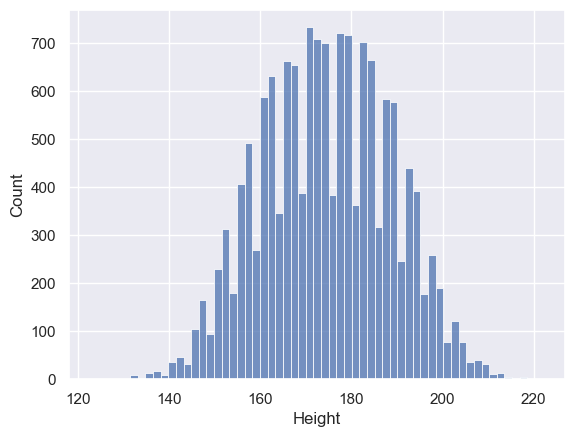

In [15]:
# Finding the distribution of 'Height' column
sns.histplot(calories_data['Height'])

<Axes: xlabel='Weight', ylabel='Count'>

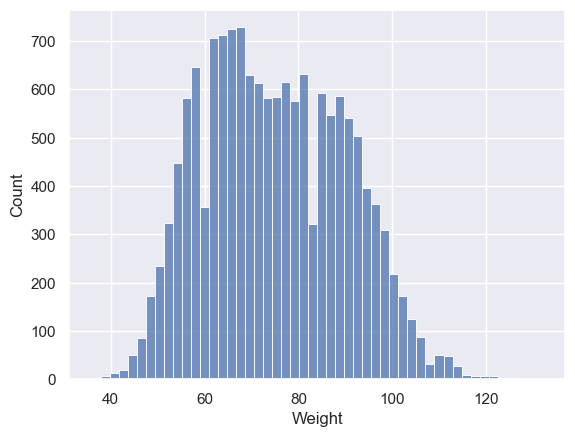

In [16]:
# finding the distribution of 'Weight' Column
sns.histplot(calories_data['Weight'])

## Finding the Correlation in the dataset

In [17]:
correlation = calories_data.corr(numeric_only=True)

<Axes: >

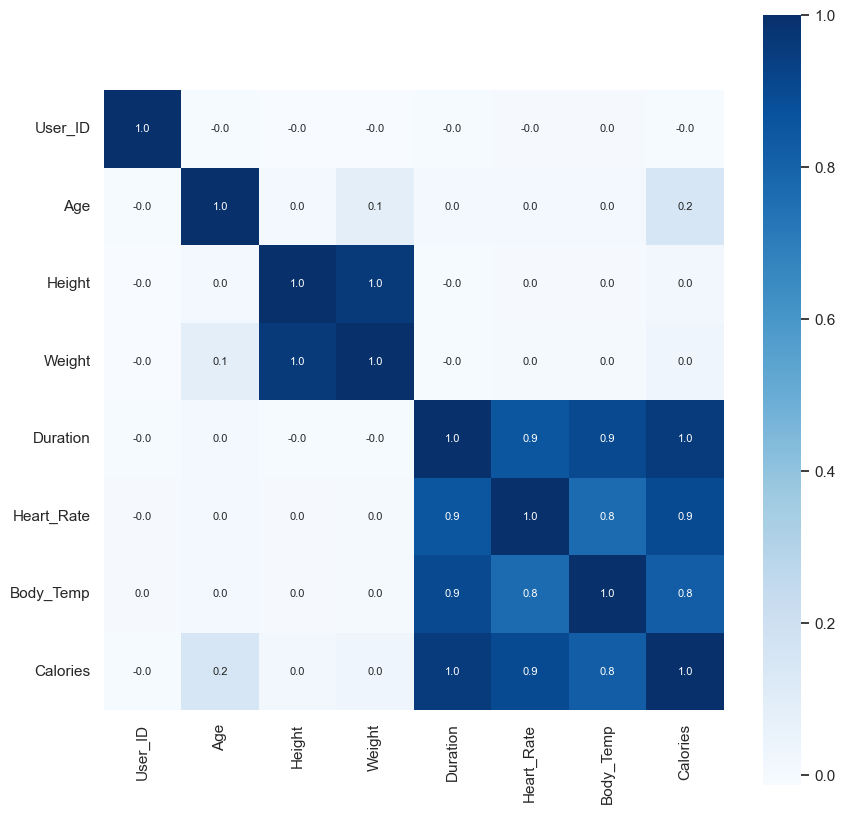

In [18]:
# Heatmap for correlation
plt.figure(figsize=(10, 10))

sns.heatmap(
    correlation,
    cbar=True,
    square=True,
    fmt='.1f',
    annot=True,
    annot_kws={'size': 8},
    cmap="Blues"
)

# Correlation ranges from -1 to +1
# +1  -> Perfect positive correlation
# Close to +1 -> Strong positive correlation
# Close to 0  -> No linear correlation
# -1  -> Perfect negative correlation
# Close to -1 -> Strong negative correlation

## Label Encoding
- converting categorical values into numerical values

In [19]:
# Encoding Gender
# male = 0
# female = 1

calories_data['Gender'] = calories_data['Gender'].map({
    'male': 0,
    'female': 1
})

In [20]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0


## Feature-Target Separation

In [21]:
# target column = Calories
# features columns = Gender, Age, Height, Weight, Duration, Heart_Rate, Body_Temp

X = calories_data.drop(columns = ['User_ID', 'Calories'], axis=1)

Y = calories_data['Calories']

In [22]:
print(X)

       Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
0           0   68   190.0    94.0      29.0       105.0       40.8
1           1   20   166.0    60.0      14.0        94.0       40.3
2           0   69   179.0    79.0       5.0        88.0       38.7
3           1   34   179.0    71.0      13.0       100.0       40.5
4           1   27   154.0    58.0      10.0        81.0       39.8
...       ...  ...     ...     ...       ...         ...        ...
14995       1   20   193.0    86.0      11.0        92.0       40.4
14996       1   27   165.0    65.0       6.0        85.0       39.2
14997       1   43   159.0    58.0      16.0        90.0       40.1
14998       0   78   193.0    97.0       2.0        84.0       38.3
14999       0   63   173.0    79.0      18.0        92.0       40.5

[15000 rows x 7 columns]


In [23]:
print(Y)

0        231.0
1         66.0
2         26.0
3         71.0
4         35.0
         ...  
14995     45.0
14996     23.0
14997     75.0
14998     11.0
14999     98.0
Name: Calories, Length: 15000, dtype: float64


## Train-Test Split

In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=2)

In [25]:
print(X.shape, X_train.shape, X_test.shape)

(15000, 7) (12000, 7) (3000, 7)


## Model Training - XGBoost Regressor

In [26]:
# loading the model
model = XGBRegressor()

In [27]:
# training the model with X_train
model.fit(X_train, Y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Evaluation

#### Prediction on test data

In [28]:
test_data_prediction = model.predict(X_test)

In [29]:
print(test_data_prediction)

[125.58828  222.11377   38.725952 ... 144.3179    23.425894  90.100494]


## MAE
* (Mean Absolute Error) to measure how far the model's predicted values are from the actual values

In [30]:
mae = metrics.mean_absolute_error(Y_test, test_data_prediction)

In [31]:
print("Mean Absolute Error = ", mae)

Mean Absolute Error =  1.4833678883314132


**RMSE** measures prediction error and gives more weight to large errors.

**R²** How well does the model predict the Calories.

In [32]:
import numpy as np

train_pred = model.predict(X_train)

train_mae = metrics.mean_absolute_error(Y_train, train_pred)
test_mae = metrics.mean_absolute_error(Y_test, test_data_prediction)

test_rmse = np.sqrt(metrics.mean_squared_error(Y_test, test_data_prediction))
test_r2 = metrics.r2_score(Y_test, test_data_prediction)

print("Train MAE :", train_mae)
print("Test MAE  :", test_mae)
print("Test RMSE :", test_rmse)
print("Test R2   :", test_r2)


Train MAE : 0.9322033420062313
Test MAE  : 1.4833678883314132
Test RMSE : 2.1704170134933394
Test R2   : 0.998800624504713


## Baseline Model Comparison - Linear Regression

In [33]:
from sklearn.linear_model import LinearRegression

baseline_model = LinearRegression()
baseline_model.fit(X_train, Y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_mae = metrics.mean_absolute_error(Y_test, baseline_pred)
baseline_r2 = metrics.r2_score(Y_test, baseline_pred)

comparison = pd.DataFrame({
    'Model': ['Linear Regression (baseline)', 'XGBoost Regressor'],
    'MAE': [baseline_mae, test_mae],
    'R2 Score': [baseline_r2, test_r2]
})

comparison


,Model,MAE,R2 Score
0,Linear Regression (baseline),8.385188,0.966879
1,XGBoost Regressor,1.483368,0.998801


## Hyperparameter Tuning

In [34]:
from sklearn.model_selection import GridSearchCV

# max_depth = how deep each tree can grow
# n_estimators = how many trees to build
param_grid = {
    'max_depth': [3, 5],
    'n_estimators': [100, 300]
}

# cv=3 means: split the training data into 3 parts and test each
# combination 3 times, then average the result
grid_search = GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3
)

grid_search.fit(X_train, Y_train)

print("Best settings found:", grid_search.best_params_)


Best settings found: {'max_depth': 3, 'n_estimators': 300}


In [35]:
# final model selection
model = grid_search.best_estimator_

tuned_prediction = model.predict(X_test)
tuned_mae = metrics.mean_absolute_error(Y_test, tuned_prediction)

print("MAE before tuning:", mae)
print("MAE after tuning :", tuned_mae)


MAE before tuning: 1.4833678883314132
MAE after tuning : 1.3820238229886939


In [36]:
tuned_r2 = metrics.r2_score(Y_test, tuned_prediction)

print("R² after tuning :", tuned_r2)

R² after tuning : 0.9990953085653546


## Feature Importance

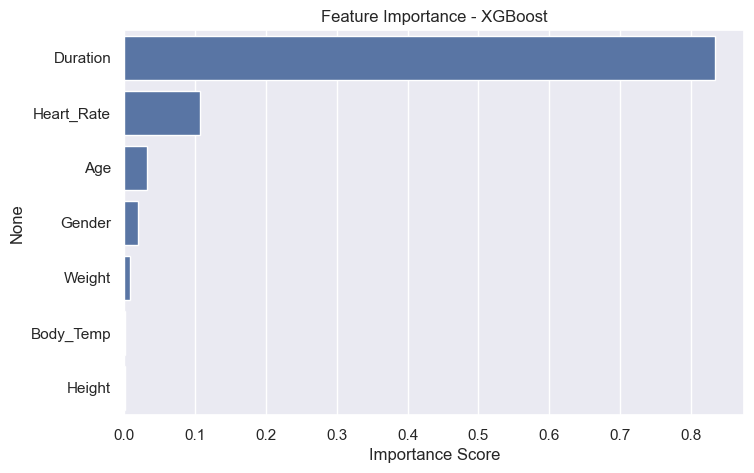

Duration      0.834144
Heart_Rate    0.106148
Age           0.031427
Gender        0.019368
Weight        0.008263
Body_Temp     0.000444
Height        0.000206
dtype: float32

In [37]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importance - XGBoost')
plt.xlabel('Importance Score')
plt.show()

importances


## Saving the Trained Model

In [38]:
import joblib

joblib.dump(model, 'calories_prediction_model.pkl')
print("Model saved as calories_prediction_model.pkl")


Model saved as calories_prediction_model.pkl


## Predictive System

In [39]:
def predict_calories(gender, age, height, weight, duration, heart_rate, body_temp):
    """
    Predict calories burnt for one person.

    Parameters
    ----------
    gender : str        'male' or 'female'
    age : float          age in years
    height : float       height in cm
    weight : float        weight in kg
    duration : float      exercise duration in minutes
    heart_rate : float    average heart rate during exercise
    body_temp : float     body temperature in Celsius during exercise

    Returns
    -------
    float : predicted calories burnt
    """
    gender_encoded = 0 if gender.lower() == 'male' else 1

    input_df = pd.DataFrame([{
        'Gender': gender_encoded,
        'Age': age,
        'Height': height,
        'Weight': weight,
        'Duration': duration,
        'Heart_Rate': heart_rate,
        'Body_Temp': body_temp
    }])

    prediction = model.predict(input_df)
    return round(float(prediction[0]), 2)


In [40]:
# Example 
predicted_calories = predict_calories(
    gender='male',
    age=28,
    height=175,
    weight=72,
    duration=25,
    heart_rate=110,
    body_temp=40.5
)

print(f"Predicted calories burnt: {predicted_calories}")


Predicted calories burnt: 156.83
